In [1]:
# CELL 1 — Load everything
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix)
import xgboost as xgb

print("✅ Libraries loaded")

# Load preprocessed data from Day 2
# First check if Day 2 output exists
day2_path = '/kaggle/input/'  
# We need to add Day 2 output as input dataset

print("\nLooking for preprocessed data...")
for root, dirs, files in os.walk('/kaggle/'):
    for f in files:
        if f.endswith('.npy') or f.endswith('.pkl'):
            print(f"  Found: {os.path.join(root, f)}")

✅ Libraries loaded

Looking for preprocessed data...


In [4]:
# CELL 2 — FIXED: Search all locations
import numpy as np
import pickle
import os

print("Searching for Day 2 files...")
found_path = None

# Search everywhere
for root, dirs, files in os.walk('/kaggle/'):
    if 'X_train.npy' in files:
        found_path = root
        print(f"✅ Found at: {root}")
        break

if found_path is None:
    print("❌ Still not found. Listing all available:")
    for root, dirs, files in os.walk('/kaggle/input/'):
        for f in files:
            print(f"  {os.path.join(root, f)}")
else:
    # Load all files
    X_train = np.load(f'{found_path}/X_train.npy')
    X_test  = np.load(f'{found_path}/X_test.npy')
    y_train = np.load(f'{found_path}/y_train.npy')
    y_test  = np.load(f'{found_path}/y_test.npy')

    with open(f'{found_path}/label_encoder.pkl', 'rb') as f:
        le = pickle.load(f)
    with open(f'{found_path}/top_features.pkl', 'rb') as f:
        top_features = pickle.load(f)

    print(f"\n✅ All files loaded!")
    print(f"   X_train : {X_train.shape}")
    print(f"   X_test  : {X_test.shape}")
    print(f"   y_train : {y_train.shape}")
    print(f"   y_test  : {y_test.shape}")
    print(f"   Classes : {len(le.classes_)}")


Searching for Day 2 files...
✅ Found at: /kaggle/input/notebooks/mchandana086/day-02-preprocessing

✅ All files loaded!
   X_train : (34182810, 20)
   X_test  : (419362, 20)
   y_train : (34182810,)
   y_test  : (419362,)
   Classes : 27


In [5]:
# CELL 3 — Evaluation helper function
def evaluate_model(name, y_true, y_pred, le):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred,
                   average='weighted',
                   zero_division=0)
    
    print(f"\n{'='*55}")
    print(f"MODEL: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}")
    
    # Classification report
    print(f"\nDetailed Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=le.classes_,
        zero_division=0))
    
    # Confusion matrix plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {name}',
              fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    fname = name.replace(' ', '_').lower()
    plt.savefig(f'cm_{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Confusion matrix saved!")
    
    return {'model': name,
            'accuracy': float(acc),
            'f1_score': float(f1)}

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


Preparing sample for Random Forest...
Training on 500,000 samples
Training Random Forest...
(Takes 3-5 minutes)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   36.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.



✅ Random Forest trained!
Evaluating on test set...


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.8s finished



MODEL: Random Forest
  Accuracy  : 0.9946 (99.46%)
  F1-Score  : 0.9950

Detailed Report:
                                        precision    recall  f1-score   support

                                BENIGN       1.00      1.00      1.00    316508
                                Botnet       0.94      1.00      0.97       147
                    Botnet - Attempted       0.43      1.00      0.60       814
                                  DDoS       1.00      1.00      1.00     19029
                         DoS GoldenEye       1.00      1.00      1.00      1514
             DoS GoldenEye - Attempted       0.38      1.00      0.55        16
                              DoS Hulk       1.00      1.00      1.00     31694
                  DoS Hulk - Attempted       0.00      0.00      0.00       116
                      DoS Slowhttptest       0.97      1.00      0.99       348
          DoS Slowhttptest - Attempted       1.00      0.17      0.29       674
                         DoS

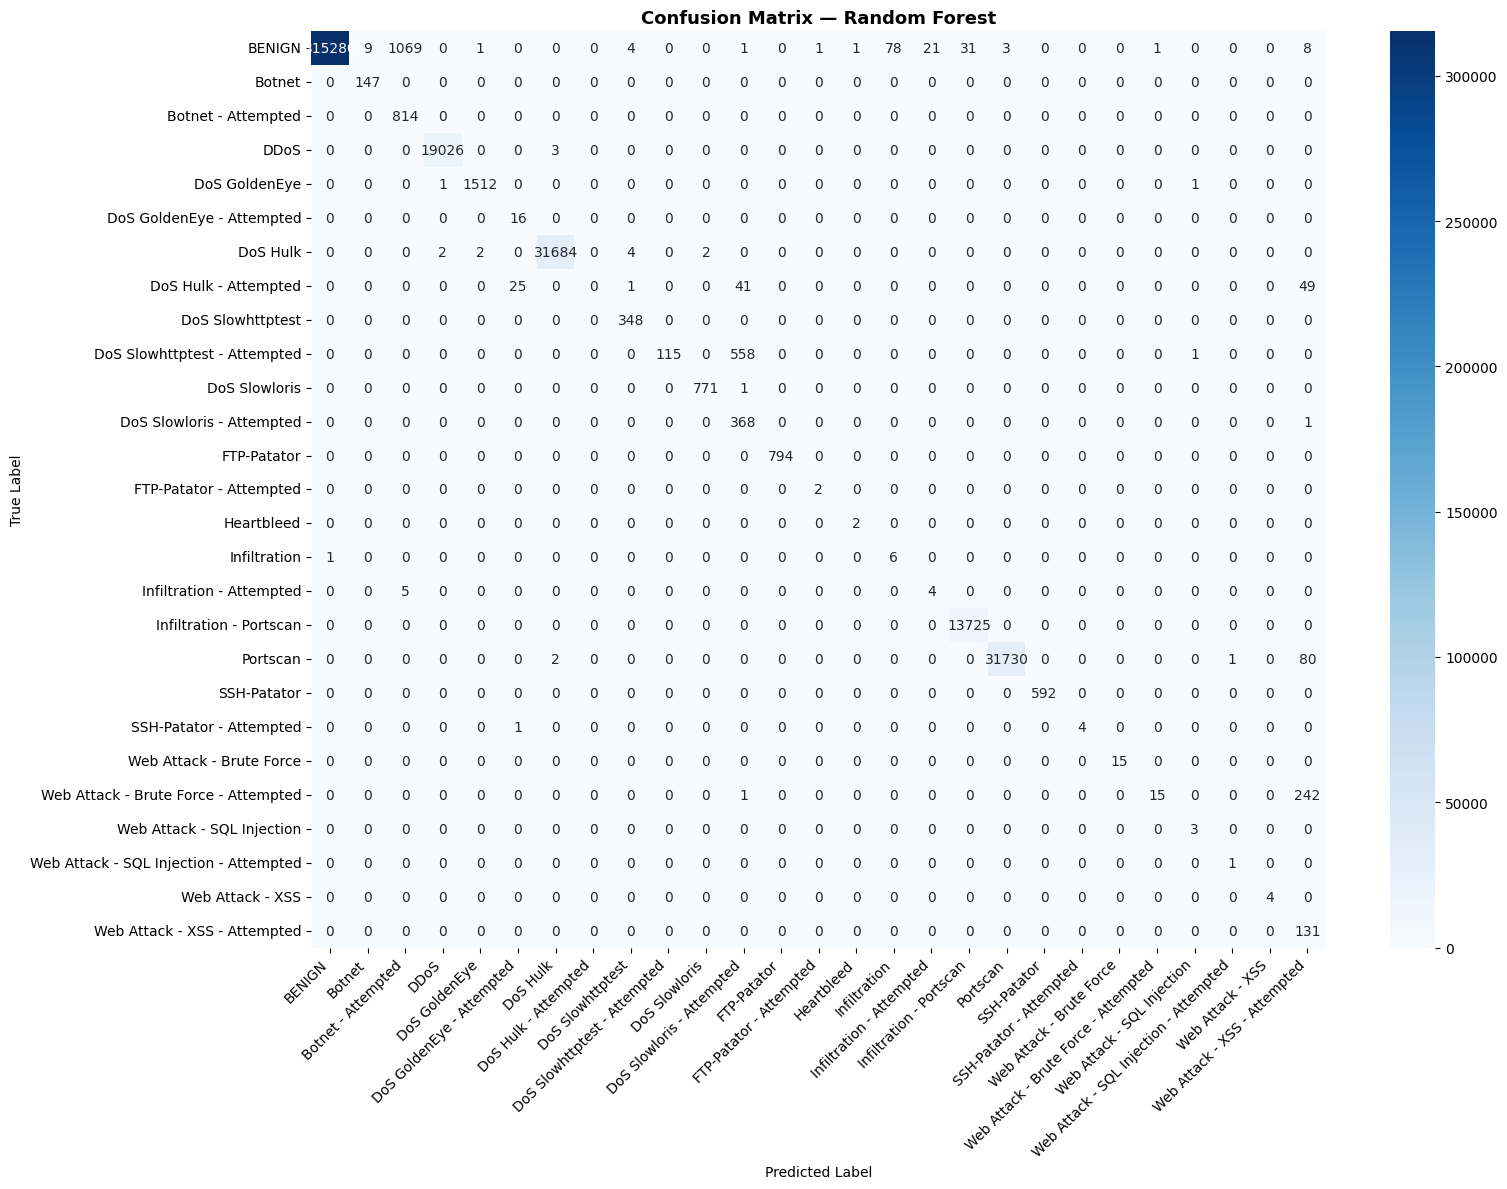

✅ Confusion matrix saved!


In [6]:
# CELL 4 — Random Forest
# Use 500K sample — RF cannot handle 34M rows efficiently
print("Preparing sample for Random Forest...")
sample_size = 500000
idx = np.random.choice(len(X_train),
                        sample_size,
                        replace=False)
X_train_rf = X_train[idx]
y_train_rf = y_train[idx]

print(f"Training on {sample_size:,} samples")
print("Training Random Forest...")
print("(Takes 3-5 minutes)")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf.fit(X_train_rf, y_train_rf)

print("\n✅ Random Forest trained!")
print("Evaluating on test set...")

y_pred_rf = rf.predict(X_test)
results_rf = evaluate_model(
    "Random Forest", y_test, y_pred_rf, le)

Training XGBoost...
(Takes 5-8 minutes)
[0]	validation_0-mlogloss:2.03678
[50]	validation_0-mlogloss:0.03457
[100]	validation_0-mlogloss:0.02315
[150]	validation_0-mlogloss:0.02285
[199]	validation_0-mlogloss:0.02280

✅ XGBoost trained!

MODEL: XGBoost
  Accuracy  : 0.9944 (99.44%)
  F1-Score  : 0.9948

Detailed Report:
                                        precision    recall  f1-score   support

                                BENIGN       1.00      1.00      1.00    316508
                                Botnet       0.91      1.00      0.95       147
                    Botnet - Attempted       0.43      1.00      0.60       814
                                  DDoS       1.00      1.00      1.00     19029
                         DoS GoldenEye       1.00      1.00      1.00      1514
             DoS GoldenEye - Attempted       0.38      1.00      0.55        16
                              DoS Hulk       1.00      1.00      1.00     31694
                  DoS Hulk - Attempte

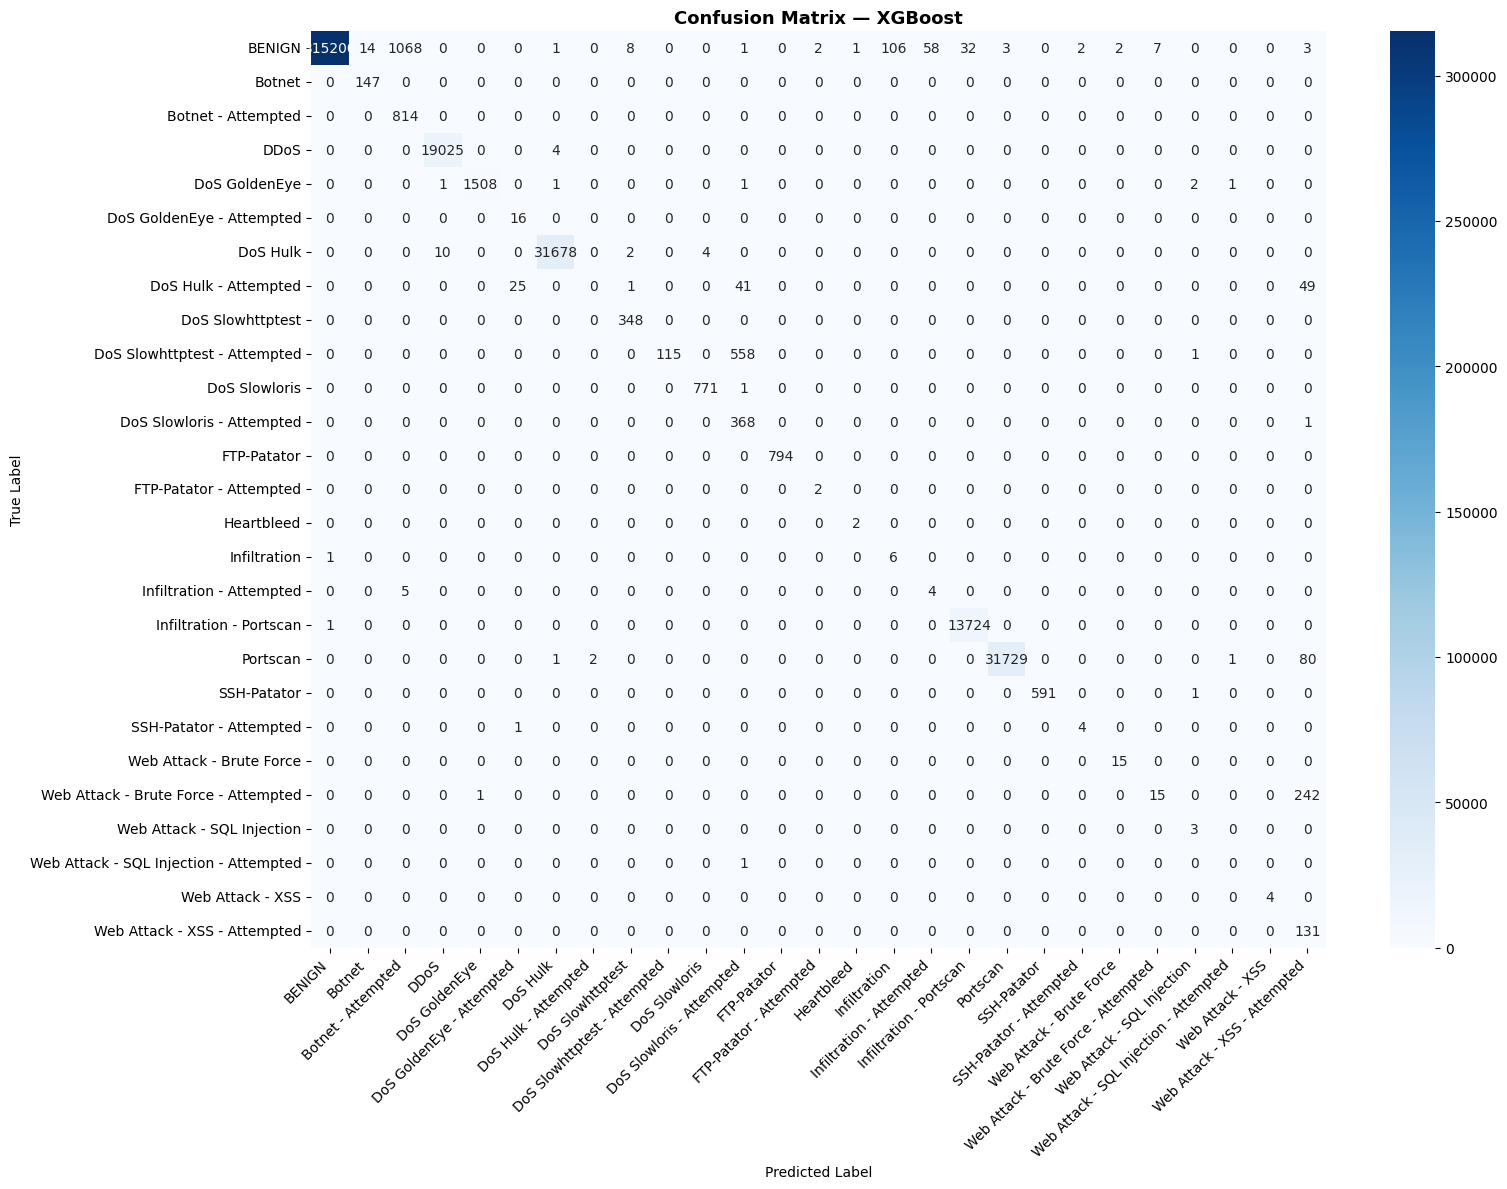

✅ Confusion matrix saved!


In [7]:
# CELL 5 — XGBoost
print("Training XGBoost...")
print("(Takes 5-8 minutes)")

# XGBoost handles large data better
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

# Use same sample as RF for fair comparison
xgb_model.fit(
    X_train_rf, y_train_rf,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ XGBoost trained!")
y_pred_xgb = xgb_model.predict(X_test)
results_xgb = evaluate_model(
    "XGBoost", y_test, y_pred_xgb, le)


MODEL COMPARISON:
Model                  Accuracy   F1-Score
---------------------------------------------
Random Forest            99.46%     0.9950
XGBoost                  99.44%     0.9948


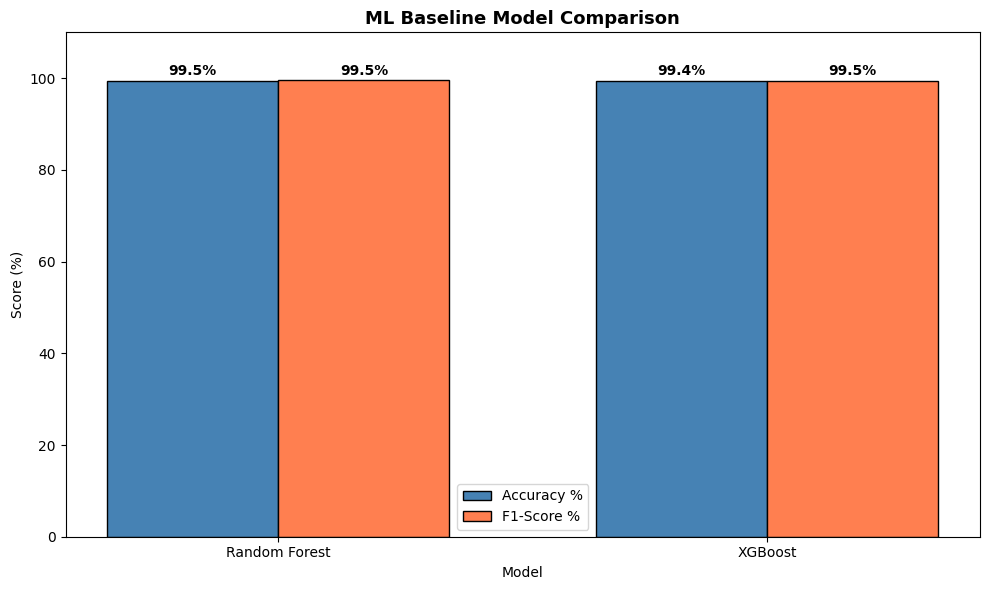

✅ Comparison chart saved!


In [8]:
# CELL 6 — Compare models
all_results = [results_rf, results_xgb]

print("\nMODEL COMPARISON:")
print("=" * 45)
print(f"{'Model':<20} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 45)
for r in all_results:
    print(f"{r['model']:<20} "
          f"{r['accuracy']*100:>9.2f}% "
          f"{r['f1_score']:>10.4f}")

# Bar chart comparison
names = [r['model'] for r in all_results]
accs  = [r['accuracy']*100 for r in all_results]
f1s   = [r['f1_score']*100 for r in all_results]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accs, width,
               label='Accuracy %',
               color='steelblue',
               edgecolor='black')
bars2 = ax.bar(x + width/2, f1s, width,
               label='F1-Score %',
               color='coral',
               edgecolor='black')

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('ML Baseline Model Comparison',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 110)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ml_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [9]:
# CELL 7 — Save all results
import json

with open('ml_baseline_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

# Save models
import pickle
with open('random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)
xgb_model.save_model('xgboost.json')

print("✅ ALL DAY 3 FILES SAVED:")
for fname in sorted(os.listdir('/kaggle/working/')):
    if not fname.startswith('.'):
        size = os.path.getsize(
               f'/kaggle/working/{fname}'
               ) // 1024 // 1024
        print(f"  └── {fname:<35s} {size:>4} MB")

print(f"\n🎉 DAY 3 ML BASELINE COMPLETE!")
print(f"\nRandom Forest → Accuracy: "
      f"{results_rf['accuracy']*100:.2f}%")
print(f"XGBoost       → Accuracy: "
      f"{results_xgb['accuracy']*100:.2f}%")
print(f"\n✅ Ready for Day 4 — CNN-LSTM Model!")

✅ ALL DAY 3 FILES SAVED:
  └── cm_random_forest.png                   0 MB
  └── cm_xgboost.png                         0 MB
  └── ml_baseline_results.json               0 MB
  └── ml_comparison.png                      0 MB
  └── random_forest.pkl                     30 MB
  └── xgboost.json                           8 MB

🎉 DAY 3 ML BASELINE COMPLETE!

Random Forest → Accuracy: 99.46%
XGBoost       → Accuracy: 99.44%

✅ Ready for Day 4 — CNN-LSTM Model!
